# EDA Project 2: Mental Health Depression Disorder Dataset

This Project performs Exploratory Data Analysis on a mental health depression disorder dataset. The analysis includes data preparation, data cleaning, visual analysis, relationship analysis and conclusion.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df2 = pd.read_csv("../data/Mental health Depression disorder Data.csv")

df2.head()

/var/folders/x7/y6tgm4cx59b_h1mvq_q_rrth0000gn/T/ipykernel_3904/2039951294.py:7: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("../data/Mental health Depression disorder Data.csv")


,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0,Afghanistan,AFG,1990,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260


## Phase 1: Data Preparation

The mental health depression disorder dataset was loaded into a Pandas DataFrame using `pd.read_csv()`. The first five rows were displayed using `df2.head()` to check whether the dataset was loaded correctly and to understand its structure.

The dataset contains mental health disorder percentage records across different countries and years. Each row represents a country-year record, while the columns describe the percentage of different mental health disorders such as schizophrenia, bipolar disorder, eating disorders, anxiety disorders, depression, drug use disorders and alcohol use disorders.

The dataset is suitable for Exploratory Data Analysis because it contains categorical variables such as country/entity and code, numerical variables such as disorder percentages and a time-based variable such as year. This allows analysis of mental health patterns across countries, years and disorder types.

There is no fixed target variable because this project focuses on EDA. However, if the dataset was later used for machine learning, `Depression (%)` could be treated as a possible target variable.

In [2]:
print("Total number of rows:", df2.shape[0])
print("Total number of columns:", df2.shape[1])

print("\nColumn names:")
print(df2.columns)

print("\nData types:")
print(df2.dtypes)

Total number of rows: 108553
Total number of columns: 11

Column names:
Index(['index', 'Entity', 'Code', 'Year', 'Schizophrenia (%)',
       'Bipolar disorder (%)', 'Eating disorders (%)', 'Anxiety disorders (%)',
       'Drug use disorders (%)', 'Depression (%)',
       'Alcohol use disorders (%)'],
      dtype='object')

Data types:
index                          int64
Entity                        object
Code                          object
Year                          object
Schizophrenia (%)             object
Bipolar disorder (%)          object
Eating disorders (%)          object
Anxiety disorders (%)        float64
Drug use disorders (%)       float64
Depression (%)               float64
Alcohol use disorders (%)    float64
dtype: object


In [3]:
# Create column summary table
column_summary2 = pd.DataFrame({
    "Column Name": df2.columns,
    "Data Type": df2.dtypes.astype(str).values
})

display(column_summary2)

,Column Name,Data Type
0,index,int64
1,Entity,object
2,Code,object
3,Year,object
4,Schizophrenia (%),object
5,Bipolar disorder (%),object
6,Eating disorders (%),object
7,Anxiety disorders (%),float64
8,Drug use disorders (%),float64
9,Depression (%),float64


## 2. Data Cleaning

### 2.1 Missing Values

Missing values were checked in every column to identify incomplete data.

In [4]:
# Check missing values in each column
missing_values2 = df2.isnull().sum()
missing_percentage2 = (df2.isnull().sum() / len(df2)) * 100

missing_summary2 = pd.DataFrame({
    "Missing Values": missing_values2,
    "Missing Percentage": missing_percentage2
})

display(missing_summary2)

,Missing Values,Missing Percentage
index,0,0.000000
Entity,0,0.000000
Code,5412,4.985583
Year,0,0.000000
Schizophrenia (%),82678,76.163717
Bipolar disorder (%),89147,82.123018
Eating disorders (%),8317,7.661695
Anxiety disorders (%),102085,94.041620
Drug use disorders (%),102085,94.041620
Depression (%),102085,94.041620


In [5]:
# Convert columns that should be numeric into proper numeric data types

numeric_columns2 = [
    "Year",
    "Schizophrenia (%)",
    "Bipolar disorder (%)",
    "Eating disorders (%)",
    "Anxiety disorders (%)",
    "Drug use disorders (%)",
    "Depression (%)",
    "Alcohol use disorders (%)"
]

for col in numeric_columns2:
    df2[col] = pd.to_numeric(df2[col], errors="coerce")

# Check data types again
print(df2.dtypes)

index                          int64
Entity                        object
Code                          object
Year                         float64
Schizophrenia (%)            float64
Bipolar disorder (%)         float64
Eating disorders (%)         float64
Anxiety disorders (%)        float64
Drug use disorders (%)       float64
Depression (%)               float64
Alcohol use disorders (%)    float64
dtype: object


In [6]:
# Check missing values again after numeric conversion
missing_after_conversion = df2.isnull().sum()

missing_after_conversion

index                             0
Entity                            0
Code                           5412
Year                            143
Schizophrenia (%)             82681
Bipolar disorder (%)          89149
Eating disorders (%)           8319
Anxiety disorders (%)        102085
Drug use disorders (%)       102085
Depression (%)               102085
Alcohol use disorders (%)    102085
dtype: int64

In [7]:
# Missing values and percentages after conversion
missing_after_conversion_summary = pd.DataFrame({
    "Missing Values": df2.isnull().sum(),
    "Missing Percentage": (df2.isnull().sum() / len(df2)) * 100
})

display(missing_after_conversion_summary)

,Missing Values,Missing Percentage
index,0,0.000000
Entity,0,0.000000
Code,5412,4.985583
Year,143,0.131733
Schizophrenia (%),82681,76.166481
Bipolar disorder (%),89149,82.124861
Eating disorders (%),8319,7.663538
Anxiety disorders (%),102085,94.041620
Drug use disorders (%),102085,94.041620
Depression (%),102085,94.041620


In [8]:
# Create a cleaned copy of the dataset
df2_cleaned = df2.copy()

# Remove rows where Year is missing because year is needed for time-based analysis
df2_cleaned = df2_cleaned.dropna(subset=["Year"])

# Replace missing Code values with "Unknown" because Code is categorical and not always available
df2_cleaned["Code"] = df2_cleaned["Code"].fillna("Unknown")

# For the main analysis, keep rows where Depression (%) is available
df2_cleaned = df2_cleaned.dropna(subset=["Depression (%)"])

print("Original dataset shape:", df2.shape)
print("Cleaned dataset shape:", df2_cleaned.shape)

Original dataset shape: (108553, 11)
Cleaned dataset shape: (6468, 11)


**Missing Values Treatment:**  
After converting the numerical columns into proper numeric format, missing values were checked again. Some missing values appeared because invalid or non-numeric values were converted into `NaN`. Rows with missing `Year` values were removed because year is important for time-based analysis. Missing values in the `Code` column were replaced with `"Unknown"` because it is a categorical identifier and some entities may not have a country code. For the main analysis, rows with missing `Depression (%)` values were removed because depression percentage is the main variable used in this project. After cleaning, the dataset shape changed from 108,553 rows and 11 columns to 6,468 rows and 11 columns.

### 2.2 Duplicate Records

Duplicate records were checked to make sure that the same country-year mental health record was not counted more than once.

In [9]:
# Check duplicate rows in the cleaned dataset
duplicate_count2 = df2_cleaned.duplicated().sum()

print("Number of duplicate rows found:", duplicate_count2)

# Remove duplicate rows
df2_cleaned = df2_cleaned.drop_duplicates()

print("Number of duplicate rows removed:", duplicate_count2)
print("New dataset shape after duplicate removal:", df2_cleaned.shape)

Number of duplicate rows found: 0
Number of duplicate rows removed: 0
New dataset shape after duplicate removal: (6468, 11)


### 2.3 Outlier Detection Using IQR

Outliers were checked using the Interquartile Range (IQR) method. Two numerical columns, `Depression (%)` and `Anxiety disorders (%)` were selected because they are important mental health indicators in the dataset.

In [10]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)

# Apply IQR method to selected mental health columns
selected_columns2 = ["Depression (%)", "Anxiety disorders (%)"]

for column in selected_columns2:
    Q1, Q3, IQR, lower_bound, upper_bound, outlier_count = detect_outliers_iqr(df2_cleaned, column)
    
    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of outliers:", outlier_count)
    print("-" * 40)

Column: Depression (%)
Q1: 3.00552875
Q3: 3.912381
IQR: 0.90685225
Lower Bound: 1.6452503749999998
Upper Bound: 5.272659375
Number of outliers: 99
----------------------------------------
Column: Anxiety disorders (%)
Q1: 3.188824
Q3: 4.682162999999999
IQR: 1.4933389999999993
Lower Bound: 0.9488155000000007
Upper Bound: 6.922171499999998
Number of outliers: 123
----------------------------------------


**Outlier Observation:**  
The IQR method was applied to `Depression (%)` and `Anxiety disorders (%)`. For `Depression (%)`, the lower bound was 1.6452 and the upper bound was 5.2726 with 99 outliers detected. For `Anxiety disorders (%)`, the lower bound was 0.9488 and the upper bound was 6.9221, with 123 outliers detected.

The outliers were retained because they may represent real differences in mental health disorder percentages across countries and years. Since this dataset compares mental health patterns globally, unusually high or low values may provide important insights rather than being data errors.

### 2.4 Summary of Data Cleaning

During the data cleaning process, missing values, duplicate records and outliers were checked. Some numerical columns were initially read as text, so they were converted into proper numeric format using `pd.to_numeric()`. After conversion, invalid values became missing values. Rows with missing `Year` values were removed because year is important for time-based analysis. Missing values in the `Code` column were replaced with `"Unknown"` and rows with missing `Depression (%)` values were removed because depression percentage was used as the main analysis variable.

The dataset shape changed from 108,553 rows and 11 columns to 6,468 rows and 11 columns after cleaning. No duplicate records were found. Outliers were detected in both `Depression (%)` and `Anxiety disorders (%)` but they were retained because they may represent valid country-year differences in mental health patterns.

## 3. Analysis and Insights

### 3.1 Single Column Analysis

A single numerical column and a single categorical column were analysed to understand their individual distributions.

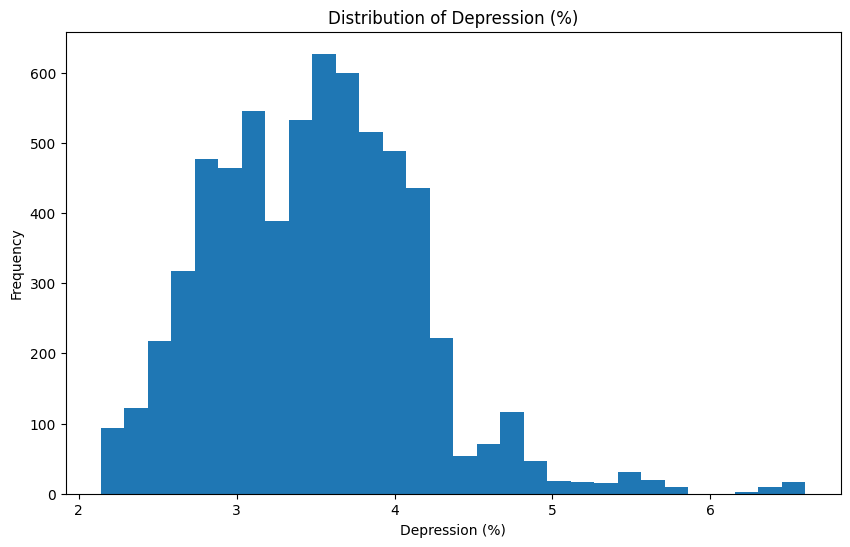

In [11]:
# Histogram for Depression (%)
plt.figure(figsize=(10, 6))
plt.hist(df2_cleaned["Depression (%)"], bins=30)

plt.title("Distribution of Depression (%)")
plt.xlabel("Depression (%)")
plt.ylabel("Frequency")
plt.show()

**Numerical Column Observation:**  
The histogram of `Depression (%)` shows how depression percentage values are distributed across the cleaned dataset. Most records are concentrated within a smaller percentage range while a few records have higher depression percentage values. This suggests that depression levels vary across different countries and years with some country-year records showing unusually higher values.

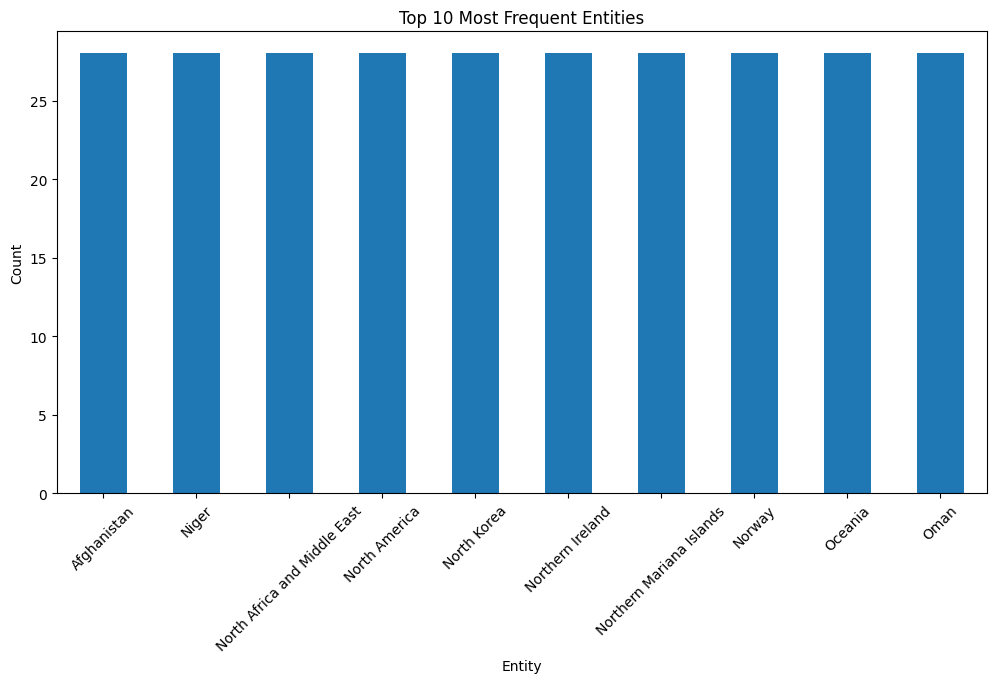

In [12]:
# Bar chart for top 10 most frequent entities
plt.figure(figsize=(12, 6))

df2_cleaned["Entity"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Frequent Entities")
plt.xlabel("Entity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [13]:
entity_counts = df2_cleaned["Entity"].value_counts()

print("Most common entity:", entity_counts.idxmax(), "-", entity_counts.max())
print("Least common entity:", entity_counts.idxmin(), "-", entity_counts.min())

Most common entity: Afghanistan - 28
Least common entity: Afghanistan - 28


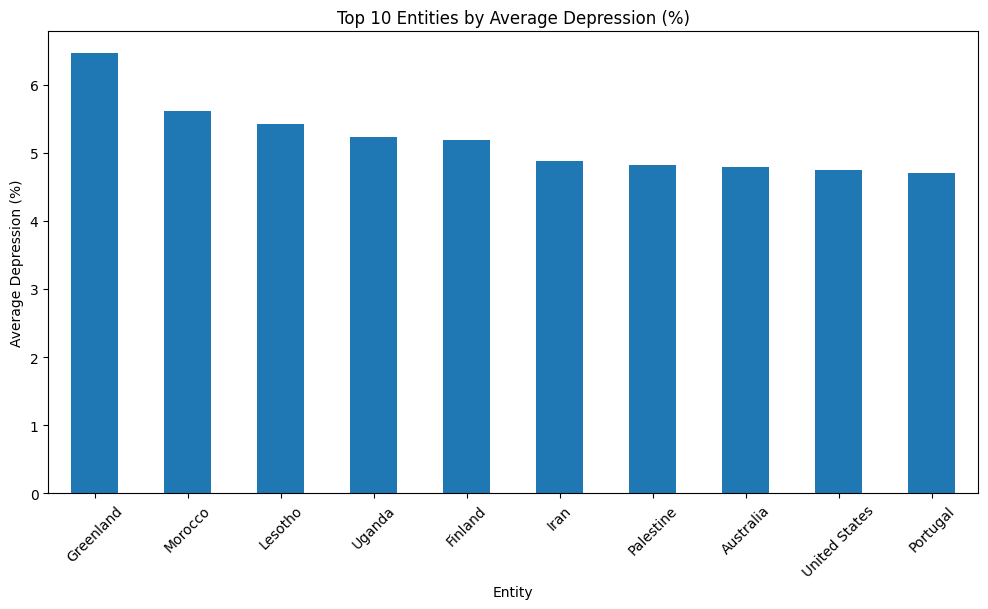

In [14]:
# Top 10 entities by average Depression (%)
top_depression_entities = (
    df2_cleaned.groupby("Entity")["Depression (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_depression_entities.plot(kind="bar")

plt.title("Top 10 Entities by Average Depression (%)")
plt.xlabel("Entity")
plt.ylabel("Average Depression (%)")
plt.xticks(rotation=45)
plt.show()

**Categorical Column Observation:**  
The `Entity` column represents countries or regions in the dataset. Since many entities have the same number of yearly records, a simple frequency count is not very useful. Therefore, the analysis compared entities based on their average `Depression (%)`. The bar chart shows the top 10 entities with the highest average depression percentages which helps identify where depression levels appear higher across the recorded years.

### 3.2 Relationship Between Two Columns

A correlation heatmap was created to examine the relationships between numerical mental health disorder percentage columns.

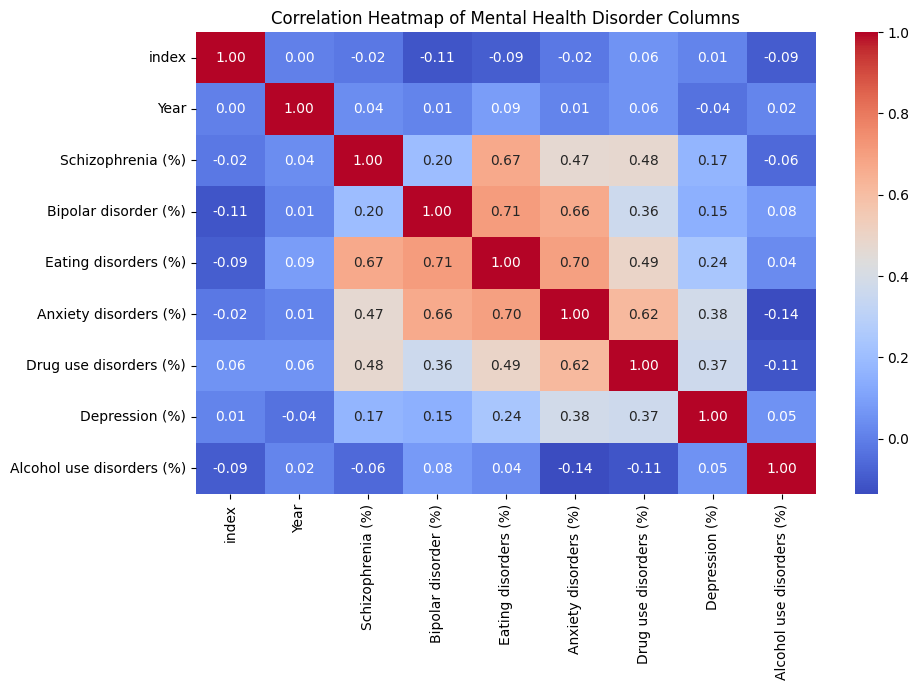

In [15]:
# Select numerical columns only
numeric_df2 = df2_cleaned.select_dtypes(include=["int64", "float64"])

# Create correlation matrix
correlation_matrix2 = numeric_df2.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix2, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Mental Health Disorder Columns")
plt.show()

In [16]:
# Find strongest correlation excluding self-correlation
corr_pairs2 = correlation_matrix2.unstack()

# Remove self-correlation values where correlation is exactly 1
corr_pairs2 = corr_pairs2[corr_pairs2 < 1]

# Sort values from strongest to weakest
strongest_corr2 = corr_pairs2.sort_values(ascending=False).head(1)

print("Strongest correlation:")
print(strongest_corr2)

Strongest correlation:
Bipolar disorder (%)  Eating disorders (%)    0.708055
dtype: float64


### Scatter Plot: Bipolar Disorder (%) vs Eating Disorders (%)

A scatter plot was created to visually examine the relationship between `Bipolar disorder (%)` and `Eating disorders (%)`.

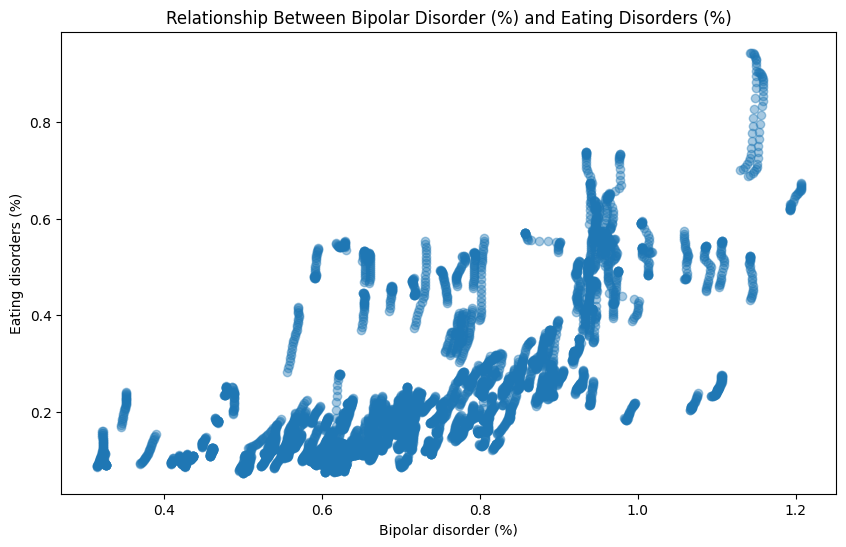

In [17]:
# Scatter plot between Bipolar disorder (%) and Eating disorders (%)
plt.figure(figsize=(10, 6))

plt.scatter(
    df2_cleaned["Bipolar disorder (%)"],
    df2_cleaned["Eating disorders (%)"],
    alpha=0.4
)

plt.title("Relationship Between Bipolar Disorder (%) and Eating Disorders (%)")
plt.xlabel("Bipolar disorder (%)")
plt.ylabel("Eating disorders (%)")
plt.show()

**Scatter Plot Observation:**  
The scatter plot between `Bipolar disorder (%)` and `Eating disorders (%)` shows a positive relationship. As bipolar disorder percentages increase, eating disorder percentages also tend to increase. This supports the correlation heatmap result, where these two columns had the strongest correlation value of 0.708. However, this relationship does not prove causation; it only shows that the two variables move together in the dataset.

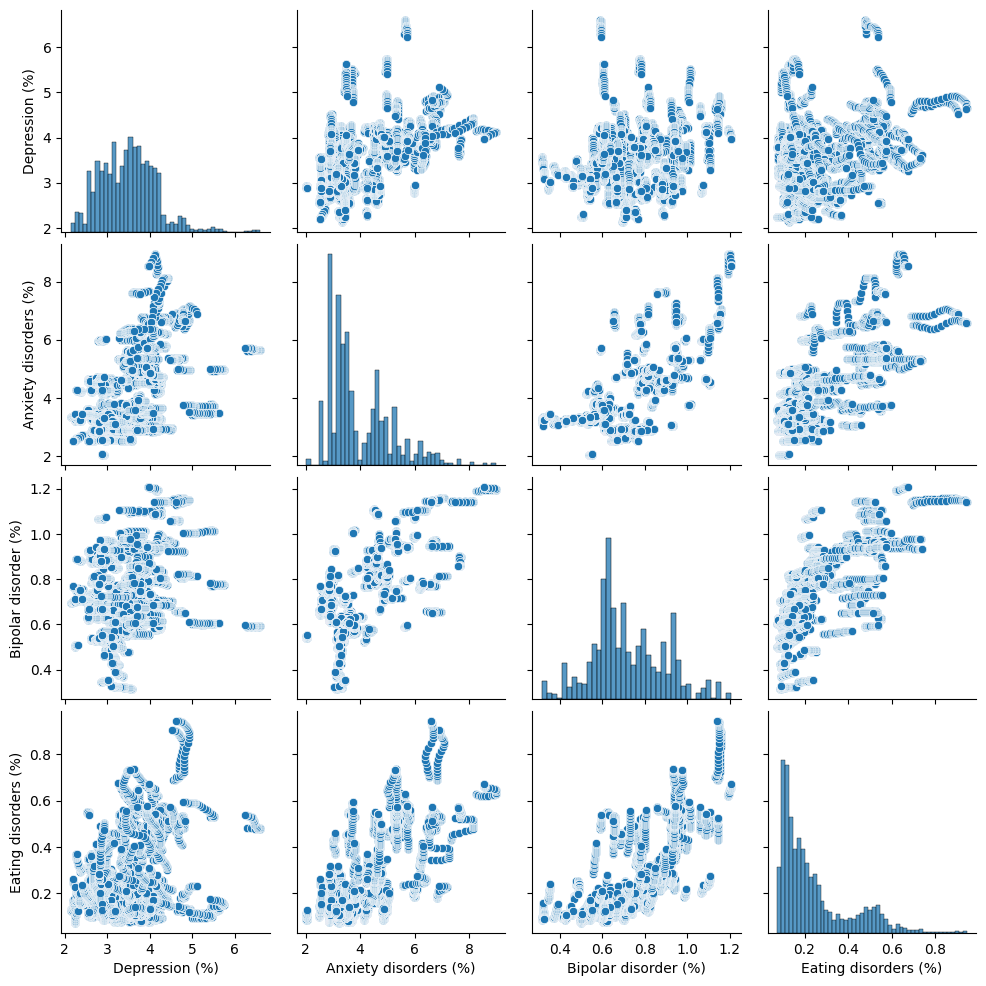

In [18]:
# Pair plot using selected mental health disorder columns
selected_pairplot_columns2 = [
    "Depression (%)",
    "Anxiety disorders (%)",
    "Bipolar disorder (%)",
    "Eating disorders (%)"
]

sns.pairplot(df2_cleaned[selected_pairplot_columns2])
plt.show()

**Pair Plot Observation:**  
The pair plot shows the relationships between `Depression (%)`, `Anxiety disorders (%)`, `Bipolar disorder (%)` and `Eating disorders (%)`. The clearest pattern is between `Bipolar disorder (%)` and `Eating disorders (%)` where the points generally move upward together. This supports the earlier correlation result where these two variables had the strongest positive relationship. The diagonal plots also show that some disorder percentages, especially `Eating disorders (%)` are right-skewed which means most values are lower while a smaller number of records have higher values. This insight is useful because it shows that some mental health disorder indicators may increase together across country-year records.

### 3.4 Summary of Findings

The single-column analysis showed that `Depression (%)` values are concentrated within a smaller percentage range, with some higher values appearing in a few records. The entity-based analysis showed that comparing countries or regions by average depression percentage is more meaningful than simply counting how often each entity appears because many entities have the same number of yearly records.

The correlation heatmap showed that the strongest relationship was between `Bipolar disorder (%)` and `Eating disorders (%)` with a correlation value of 0.708. This indicates a strong positive relationship which means that records with higher bipolar disorder percentages also tend to have higher eating disorder percentages.

The scatter plot and pair plot both supported this relationship. Overall, the dataset shows useful patterns between different mental health disorder percentages across countries and years.

In [19]:
df2_cleaned.to_csv("../data/cleaned_mental_health_disorder.csv", index=False)